# Taller (Colab) — Regresión lineal múltiple: coeficientes, significancia y residuales

**Duración sugerida:** 50–60 min de trabajo + sustentación.

## Qué se evalúa hoy
1) **Interpretación de coeficientes** en regresión múltiple (cambio marginal, controlando por, unidades).
2) **Significancia por coeficiente** (t y p-valor, y coherencia con el IC).
3) **Lectura de residuales** (qué dicen y qué alertas sugieren).

---
## Definiciones mínimas (úsalas textual en la sustentación)

### A. Interpretación correcta de un coeficiente (plantilla obligatoria)
Para un predictor Xj:
> “Si Xj aumenta en **1 unidad**, la **nota esperada** cambia en **β̂j** puntos, **manteniendo constantes** los demás predictores del modelo.”

**Siempre debes mencionar:**
- signo (sube/baja),
- magnitud (cuánto),
- unidad (puntos de nota por unidad de Xj),
- y la frase “manteniendo constantes …”.

### B. Significancia (por coeficiente)
- Hipótesis: H0: βj = 0 vs H1: βj ≠ 0.
- t = β̂j / SE(β̂j).
- p-valor: evidencia contra H0 bajo los supuestos del modelo.

### C. Residuales (qué mirar)
- Residual = observado − predicho.
- Si hay patrón (curva/abanico) en residuales vs predichos → posible problema (no linealidad/heterocedasticidad).
- Outliers: residuales muy grandes en valor absoluto.


In [ ]:
# 0) LIBRERÍAS (NO MODIFICAR)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

np.random.seed(2026)
pd.set_option('display.precision', 4)


## Contexto y variables (común para todos)

**Unidad:** estudiante.

**Y:** `nota` (0 a 5)

**X:**
- `horas` = horas de estudio por semana
- `asistencia` = porcentaje de asistencia (0–100)
- `promedio` = promedio previo (0–5)


In [ ]:
# 1) SIMULACIÓN BASE (NO MODIFICAR)
n = 300

promedio = np.clip(np.random.normal(3.5, 0.5, n), 0, 5)
asistencia = 70 + 8*(promedio-3.5) + np.random.normal(0, 10, n)
asistencia = np.clip(asistencia, 40, 100)
horas = 6 + 2.0*(promedio-3.5) + 0.05*(asistencia-70) + np.random.normal(0, 2.5, n)
horas = np.clip(horas, 0, 25)

eps = np.random.normal(0, 0.35, n)
nota = 0.6 + 0.05*horas + 0.012*asistencia + 0.55*promedio + eps
nota = np.clip(nota, 0, 5)

df = pd.DataFrame({'nota': nota, 'horas': horas, 'asistencia': asistencia, 'promedio': promedio})
df.head()

,nota,horas,asistencia,promedio
0,3.1953,2.2842,52.2924,3.2841
1,3.5160,4.6165,64.9618,2.8036
2,3.9114,2.5652,81.6452,3.6558
3,4.0231,8.3381,63.5462,3.4934
4,4.1592,12.3759,76.2580,4.2249


# Instrucciones del taller (USTEDES escriben el código)

## Entrega: 3 cosas
1) Tu notebook con el código.
2) Un párrafo final (8–10 líneas).
3) 2 gráficas guardadas en el notebook.

---
## Tareas (claras y numeradas)

### Parte 1 — Ajuste del modelo y coeficientes (interpretación)
1. Ajusta el modelo **M3**: `nota ~ horas + asistencia + promedio`.
2. Copia (o muestra) la tabla de coeficientes.
3. Interpreta **cada** coeficiente (horas, asistencia, promedio) con la **plantilla obligatoria**.
   - incluye signo, magnitud, unidad y “manteniendo constantes …”.
4. Interpreta el efecto de **+5 horas** usando el coeficiente de `horas`.

### Parte 2 — Significancia (por coeficiente)
5. Para cada predictor (horas, asistencia, promedio), responde:
   - H0 y H1.
   - p-valor: ¿rechazas H0 al 5%?
   - IC 95%: ¿incluye 0 o no?
   - Cierra con 1 frase: “significativo” NO es lo mismo que “importante”.

### Parte 3 — Residuales (lectura rápida y profesional)
6. Calcula residuales y valores ajustados (predichos).
7. Haz estas 2 gráficas:
   - (G1) Residuales vs Ajustados (scatter) + línea horizontal en 0.
   - (G2) Histograma de residuales (o QQ plot si sabes hacerlo).
8. Escribe 3 bullets:
   - ¿ves patrón (curva/abanico) o se ve “nube” alrededor de 0?
   - ¿hay outliers evidentes?
   - ¿qué supuesto podría fallar si ves abanico?

### Parte 4 — Modificación obligatoria (para forzar nueva interpretación)
Vamos a cambiar UNIDAD de una variable y a crear un nuevo modelo.
9. Crea `horas10 = horas / 10` y ajusta el modelo **M3b**: `nota ~ horas10 + asistencia + promedio`.
10. Compara β̂_horas (M3) vs β̂_horas10 (M3b) y escribe:
   - ¿por qué cambia el número?
   - ¿cómo cambia la interpretación en palabras?

---
## Párrafo final (8–10 líneas)
Incluye:
- interpretación correcta de los 3 coeficientes (resumida),
- 1 conclusión sobre significancia (sin exagerar causalidad),
- 1 conclusión sobre residuales,
- y 1 línea sobre el cambio de unidades (horas a decenas de horas).


#Espacio de Trabajo

## Parte 1 — Ajuste del modelo y coeficientes (interpretación)
1. Ajusta el modelo **M3**: `nota ~ horas + asistencia + promedio`.
2. Copia (o muestra) la tabla de coeficientes.
3. Interpreta **cada** coeficiente (horas, asistencia, promedio) con la **plantilla obligatoria**.
   - incluye signo, magnitud, unidad y “manteniendo constantes …”.
4. Interpreta el efecto de **+5 horas** usando el coeficiente de `horas`.

In [ ]:
X = sm.add_constant(df[['horas','asistencia','promedio']])
m3 = sm.OLS(df['nota'], X).fit()

# 1) Ajusta M3
# 2) Copia (o muestra) la tabla de coeficientes.
print(m3.summary())

                            OLS Regression Results                            
Dep. Variable:                   nota   R-squared:                       0.543
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                     117.4
Date:                Mon, 09 Feb 2026   Prob (F-statistic):           4.25e-50
Time:                        16:18:13   Log-Likelihood:                -136.99
No. Observations:                 300   AIC:                             282.0
Df Residuals:                     296   BIC:                             296.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6487      0.191      3.404      0.0

###Interpretación Coeficientes



*   Si horas aumenta en **1 unidad**, la **nota esperada** cambia en **+0.00412** puntos, **manteniendo constantes** los demás predictores del modelo.
*   Si asistencia aumenta en **1 unidad**, la **nota esperada** cambia en **+0.106** puntos, **manteniendo constantes** los demás predictores del modelo.
*   Si promedio aumenta en **1 unidad**, la **nota esperada** cambia en **+0.5753** puntos, **manteniendo constantes** los demás predictores del modelo.

###Efecto +5hrs

In [ ]:
5*0.0412

0.20600000000000002

Si horas aumenta en **5 unidadES**, la **nota esperada** cambia en **+0.206** puntos, **manteniendo constantes** los demás predictores del modelo.

## Parte 2 — Significancia (por coeficiente)
5. Para cada predictor (horas, asistencia, promedio), responde:
   - H0 y H1.
   - p-valor: ¿rechazas H0 al 5%?
   - IC 95%: ¿incluye 0 o no?
   - Cierra con 1 frase: “significativo” NO es lo mismo que “importante”.

###Horas

Hipótesis:

*   $H_0: β_j = 0$
*   $H_1: β_j ≠ 0$


$t = 4.610$


$p-valor: 0.000$

IC95% = [ 0.024, 0.059 ]

No. El intervalo de confianza no incluye el cero, lo que indica que horas es diferente de $0$.


Podemos evidenciar que $0.000 < 0.05$ el p-valor obtenido para el predictor de horas, por lo tanto se rechaza la hipotesis nula al 5% que nos indicaría que efectivamente la variable horas es significativa al momento de la predicción y es diferente de 0, por lo tanto es muy improbable que llegara a ser un valor no determinante al momento de la predicción.

###Asistencia

Hipótesis:

*   $H_0: β_j = 0$
*   $H_1: β_j ≠ 0$


$t = 4.817$


$p-valor: 0.000$

IC95% = [ 0.006, 0.015 ]

No. El intervalo de confianza no incluye el cero, lo que indica que Asistencia es diferente de $0$.


Podemos evidenciar que $0.000 < 0.05$ el p-valor obtenido para el predictor de Asistencia, por lo tanto se rechaza la hipotesis nula al 5% que nos indicaría que efectivamente la variable asistencia es significativa al momento de la predicción y es diferente de 0, por lo tanto es muy improbable que llegara a ser un valor no determinante al momento de la predicción.

###Promedio

Hipótesis:

*   $H_0: β_j = 0$
*   $H_1: β_j ≠ 0$


$t = 11.422$


$p-valor: 0.000$

IC95% = [ 0.006, 0.015 ]

No. El intervalo de confianza no incluye el cero, lo que indica que promedio es diferente de $0$.


Podemos evidenciar que $0.000 < 0.05$ el p-valor obtenido para el predictor de promedio, por lo tanto se rechaza la hipotesis nula al 5% que nos indicaría que efectivamente la variable promedio es significativa al momento de la predicción y es diferente de 0, por lo tanto es muy improbable que llegara a ser un valor no determinante al momento de la predicción.

## Parte 3 — Residuales (lectura rápida y profesional)
6. Calcula residuales y valores ajustados (predichos).
7. Haz estas 2 gráficas:
   - (G1) Residuales vs Ajustados (scatter) + línea horizontal en 0.
   - (G2) Histograma de residuales (o QQ plot si sabes hacerlo).
8. Escribe 3 bullets:
   - ¿ves patrón (curva/abanico) o se ve “nube” alrededor de 0?
   - ¿hay outliers evidentes?
   - ¿qué supuesto podría fallar si ves abanico?

###Calculo de Residuales

In [ ]:
residuals = m3.resid
fitted_values = m3.fittedvalues

print("Residuals (Primeros 5):")
print(residuals.head())
print("\nFitted Values (Primeros 5):")
print(fitted_values.head())

Residuals (Primeros 5):
0    0.0073
1    0.3738
2    0.1859
3    0.3458
4   -0.2403
dtype: float64

Fitted Values (Primeros 5):
0    3.1880
1    3.1423
2    3.7254
3    3.6773
4    4.3995
dtype: float64


###Graficas

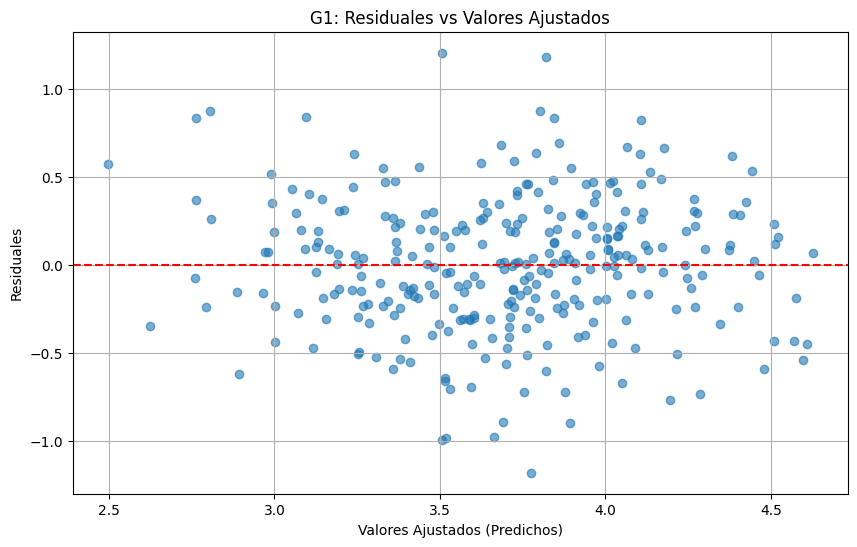

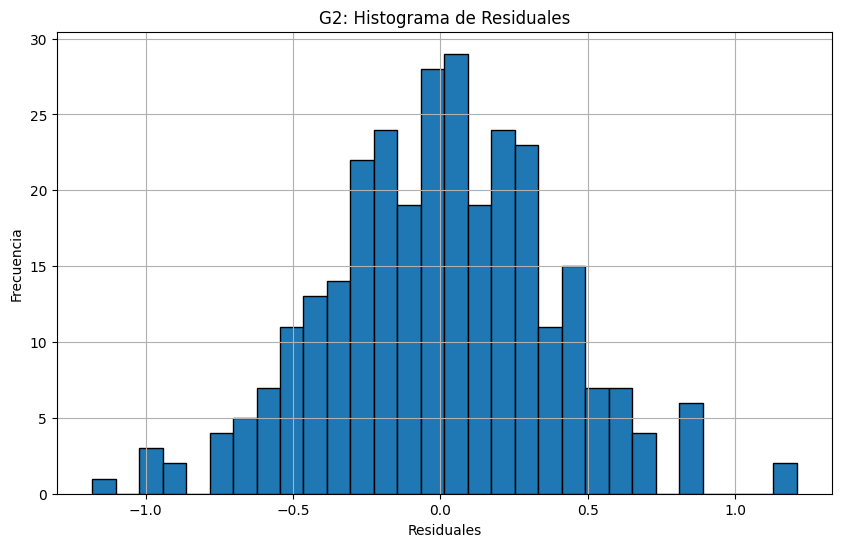

In [ ]:
# @title
import matplotlib.pyplot as plt

# G1: Residuales vs Ajustados (scatter) + línea horizontal en 0
plt.figure(figsize=(10, 6))
plt.scatter(fitted_values, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valores Ajustados (Predichos)')
plt.ylabel('Residuales')
plt.title('G1: Residuales vs Valores Ajustados')
plt.grid(True)
plt.show()

# G2: Histograma de residuales
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel('Residuales')
plt.ylabel('Frecuencia')
plt.title('G2: Histograma de Residuales')
plt.grid(True)
plt.show()

###Bullets



*   No se evidenvia una curvatura de hecho se ve claramente una nube de puntos en la grafica de G1, dandonos a entender que los puntos estan dispersos al rededor de 0, sin ninguna forma caracteristica para esta nube de puntos, lo cual nos indica que hay una relación lineal adecuada.
*   En ambas graficas podemos observar que hay valores los cuales sobrepasan la barrera de +- 1 o incluso un poco más, graficamente se ven un poco alejados pero no de una forma alarmante la cual indique que son outliers.
*   Podemos indicar que si se evidencia una forma de abanico fallaria el supueto de independencia, puesto que si existiera alguna forma se creeria que hay una relación de los datos previa, tambien fallaria el supuesto de homoscedasticidad.

## Parte 4 — Modificación obligatoria (para forzar nueva interpretación)
Vamos a cambiar UNIDAD de una variable y a crear un nuevo modelo.
9. Crea `horas10 = horas / 10` y ajusta el modelo **M3b**: `nota ~ horas10 + asistencia + promedio`.
10. Compara β̂_horas (M3) vs β̂_horas10 (M3b) y escribe:
   - ¿por qué cambia el número?
#   - ¿cómo cambia la interpretación en palabras?

In [ ]:
df['horas10'] = df['horas'] / 10
X_m3b = sm.add_constant(df[['horas10', 'asistencia', 'promedio']])
m3b = sm.OLS(df['nota'], X_m3b).fit()
print(m3b.summary())

                            OLS Regression Results                            
Dep. Variable:                   nota   R-squared:                       0.543
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                     117.4
Date:                Mon, 09 Feb 2026   Prob (F-statistic):           4.25e-50
Time:                        16:47:58   Log-Likelihood:                -136.99
No. Observations:                 300   AIC:                             282.0
Df Residuals:                     296   BIC:                             296.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6487      0.191      3.404      0.0

Ahora el numero de horas si sufre un cambio, debido que ahora esta en un unidad de medición diferente, y de esta forma el coeficiente cambia a 0.4117, debido a esto si aumentamos una unidad se vera mas afectada la nota, pero a nivel del modelo no cambia en nada, el ajuste es practimente el mismo, al igual que las mediciones obtenidas.


## Párrafo final (8–10 líneas)
Incluye:
- interpretación correcta de los 3 coeficientes (resumida),
- 1 conclusión sobre significancia (sin exagerar causalidad),
- 1 conclusión sobre residuales,
- y 1 línea sobre el cambio de unidades (horas a decenas de horas).

El modelo estimado indica que, manteniendo constantes las demás variables, por cada aumento de una decena de horas de estudio, la nota promedio del estudiante aumenta aproximadamente 0.41 puntos. Asimismo, un incremento de una unidad porcentual en la asistencia se asocia con un aumento aproximado de 0.0106 puntos en la nota, mientras que un aumento de un punto en el promedio académico previo incrementa la nota en cerca de 0.575 puntos, siendo esta la variable con mayor impacto en el modelo. Los resultados muestran que las tres variables explicativas son estadísticamente significativas, lo que sugiere que están asociadas con el rendimiento académico, sin implicar necesariamente relaciones causales. El análisis gráfico de los residuales muestra una dispersión aleatoria alrededor de cero y una distribución aproximadamente normal, lo que respalda los supuestos del modelo de regresión lineal. Finalmente, el cambio de la variable horas a decenas de horas solo modifica la escala de interpretación del coeficiente, sin afectar el ajuste ni la capacidad predictiva del modelo.